In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv('../data/sisaire/data_estaciones.csv')
df.head()

,fecha,estacion,autoridad,contaminante,concentracion,lat,lon,año,mes
0,2020-08-24 00:00:00,PALMIRA,CVC,PM25,5.40,3.537500,-76.300833,2020,8
1,2020-09-04 10:00:00,TRANSITORIA-NAVARRO,DAGMA,O3,5.96,3.417183,-76.494960,2020,9
2,2020-08-21 14:00:00,URBANO,CVC,PM10,0.00,3.411472,-76.347278,2020,8
3,2020-12-18 17:00:00,PALMIRA,CVC,PM25,10.80,3.537500,-76.300833,2020,12
4,2020-05-20 20:00:00,ERA OBRERO,DAGMA,PM10,30.90,3.457317,-76.506539,2020,5


In [17]:
selected_stations = [
    'LA ERMITA',
    'COMPARTIR',
    'UNIVERSIDAD DEL VALLE',
    'BASE AÉREA',
    'CAÑAVERALEJO',
    'LA FLORA',
    'ERA OBRERO',
    'PANCE',
    'ACOPI'
    # agrega aquí las demás estaciones hasta completar 9
]

df = df[df['estacion'].isin(selected_stations)].copy()

In [18]:
df = df[df['contaminante'].isin(['NO2', 'SO2', 'O3'])]
df.head()

,fecha,estacion,autoridad,contaminante,concentracion,lat,lon,año,mes
5,2020-07-22 11:00:00,LA ERMITA,DAGMA,SO2,0.00,3.455514,-76.530978,2020,7
14,2020-10-25 23:00:00,COMPARTIR,DAGMA,O3,13.65,3.428260,-76.466584,2020,10
23,2020-12-29 23:00:00,UNIVERSIDAD DEL VALLE,DAGMA,O3,6.65,3.377911,-76.533811,2020,12
30,2020-08-10 13:00:00,BASE AÉREA,DAGMA,SO2,0.01,3.457128,-76.502303,2020,8
31,2020-07-18 19:00:00,CAÑAVERALEJO,DAGMA,SO2,0.00,3.416366,-76.549613,2020,7


In [11]:
# Descripción general del dataset
print("=" * 80)
print("DESCRIPCIÓN GENERAL DEL DATASET")
print("=" * 80)
print(f"\nForma del dataset: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nColumns: {df.columns.tolist()}")

DESCRIPCIÓN GENERAL DEL DATASET

Forma del dataset: (65484, 9)

Tipos de datos:
fecha                str
estacion             str
autoridad            str
contaminante         str
concentracion    float64
lat              float64
lon              float64
año                int64
mes                int64
dtype: object

Columns: ['fecha', 'estacion', 'autoridad', 'contaminante', 'concentracion', 'lat', 'lon', 'año', 'mes']


In [12]:
# Análisis de valores faltantes
print("\n" + "=" * 80)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 80)
print(f"\nValores faltantes por columna:")
print(df.isnull().sum())
print(f"\nPorcentaje de valores faltantes:")
print((df.isnull().sum() / len(df) * 100).round(2))


ANÁLISIS DE VALORES FALTANTES

Valores faltantes por columna:
fecha            0
estacion         0
autoridad        0
contaminante     0
concentracion    0
lat              0
lon              0
año              0
mes              0
dtype: int64

Porcentaje de valores faltantes:
fecha            0.0
estacion         0.0
autoridad        0.0
contaminante     0.0
concentracion    0.0
lat              0.0
lon              0.0
año              0.0
mes              0.0
dtype: float64


In [13]:
# Estadísticas descriptivas generales
print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS GENERALES")
print("=" * 80)
print(df.describe())

# Info adicional
print(f"\nPrimeras filas del dataset:")
print(df.head(10))


ESTADÍSTICAS DESCRIPTIVAS GENERALES
       concentracion           lat           lon           año           mes
count   65484.000000  65484.000000  65484.000000  65484.000000  65484.000000
mean        7.738692      3.433919    -76.514154   2020.672867      6.684534
std        13.205868      0.050271      0.022320      0.917684      3.092961
min         0.000000      3.304517    -76.549613   2020.000000      1.000000
25%         0.050000      3.416366    -76.531252   2020.000000      4.000000
50%         3.830000      3.455514    -76.518058   2020.000000      7.000000
75%         8.500000      3.457317    -76.502303   2022.000000      9.000000
max       132.140000      3.488218    -76.466584   2023.000000     12.000000

Primeras filas del dataset:
                  fecha               estacion autoridad contaminante  \
5   2020-07-22 11:00:00              LA ERMITA     DAGMA          SO2   
14  2020-10-25 23:00:00              COMPARTIR     DAGMA           O3   
23  2020-12-29 23:00:0

In [19]:
print(list(df['estacion'].unique()))

['LA ERMITA', 'COMPARTIR', 'UNIVERSIDAD DEL VALLE', 'BASE AÉREA', 'CAÑAVERALEJO', 'LA FLORA', 'PANCE', 'ERA OBRERO']


In [7]:
# Análisis de contaminantes
print("\n" + "=" * 80)
print("ANÁLISIS POR CONTAMINANTE")
print("=" * 80)

contaminantes_all = df['contaminante'].unique()
print(f"\nContaminantes disponibles: {contaminantes_all}")
print(f"Total de contaminantes: {len(contaminantes_all)}")

# Conteo de mediciones por contaminante
print("\nConteo de mediciones por contaminante:")
print(df['contaminante'].value_counts())

# Estadísticas por contaminante
print("\nEstadísticas de concentración por contaminante (TODOS):")
for cont in sorted(contaminantes_all):
    data = df[df['contaminante'] == cont]['concentracion']
    print(f"\n{cont}:")
    print(f"  Media: {data.mean():.2f}")
    print(f"  Mediana: {data.median():.2f}")
    print(f"  Desv. Est.: {data.std():.2f}")
    print(f"  Mín: {data.min():.2f}")
    print(f"  Máx: {data.max():.2f}")
    print(f"  Rango: {data.max() - data.min():.2f}")


ANÁLISIS POR CONTAMINANTE

Contaminantes disponibles: <StringArray>
['O3', 'SO2', 'NO2']
Length: 3, dtype: str
Total de contaminantes: 3

Conteo de mediciones por contaminante:
contaminante
O3     99623
SO2    51483
NO2    13496
Name: count, dtype: int64

Estadísticas de concentración por contaminante (TODOS):

NO2:
  Media: 8.21
  Mediana: 6.77
  Desv. Est.: 7.06
  Mín: 0.00
  Máx: 163.90
  Rango: 163.90

O3:
  Media: 14.49
  Mediana: 7.80
  Desv. Est.: 19.20
  Mín: 0.00
  Máx: 194.90
  Rango: 194.90

SO2:
  Media: 6.26
  Mediana: 3.35
  Desv. Est.: 11.67
  Mín: 0.00
  Máx: 241.19
  Rango: 241.19


In [8]:
# Análisis por estación
print("\n" + "=" * 80)
print("ANÁLISIS POR ESTACIÓN DE MONITOREO")
print("=" * 80)

print(f"\nEstaciones disponibles: {df['estacion'].nunique()}")
print("\nListado de estaciones:")
print(df['estacion'].unique())

print("\nConteo de mediciones por estación:")
print(df['estacion'].value_counts().sort_values(ascending=False))

# Estadísticas por estación (concentración promedio)
print("\nConcentración promedio por estación:")
estacion_stats = df.groupby('estacion')['concentracion'].agg(['mean', 'count', 'min', 'max', 'std'])
estacion_stats = estacion_stats.sort_values('mean', ascending=False)
print(estacion_stats)


ANÁLISIS POR ESTACIÓN DE MONITOREO

Estaciones disponibles: 12

Listado de estaciones:
<StringArray>
[  'TRANSITORIA-NAVARRO',             'LA ERMITA',               'PALMIRA',
             'COMPARTIR', 'UNIVERSIDAD DEL VALLE',                 'MOVIL',
            'BASE AÉREA',          'CAÑAVERALEJO',              'LA FLORA',
        'ESTACIÓN YUMBO',                 'PANCE',            'ERA OBRERO']
Length: 12, dtype: str

Conteo de mediciones por estación:
estacion
ESTACIÓN YUMBO           34372
PALMIRA                  31129
MOVIL                    26182
BASE AÉREA               15080
LA FLORA                 10067
LA ERMITA                 8627
COMPARTIR                 7507
TRANSITORIA-NAVARRO       7435
ERA OBRERO                6939
UNIVERSIDAD DEL VALLE     6350
PANCE                     5861
CAÑAVERALEJO              5053
Name: count, dtype: int64

Concentración promedio por estación:
                            mean  count  min     max        std
estacion                  

In [13]:
# Análisis de relaciones entre contaminantes
print("\n" + "=" * 80)
print("ANÁLISIS DE CORRELACIONES ENTRE CONTAMINANTES")
print("=" * 80)

# Crear tabla pivote para correlaciones
contaminantes_filtrados = ['NO2', 'SO2', 'O3']
df_filtered = df[df['contaminante'].isin(contaminantes_filtrados)].copy()

# Crear tabla pivote por estación
for estacion in df['estacion'].unique()[:3]:  # Primeras 3 estaciones
    print(f"\nEstación: {estacion}")
    df_estacion = df_filtered[df_filtered['estacion'] == estacion].copy()
    
    # Crear pivot table
    pivot = df_estacion.pivot_table(
        index='fecha',
        columns='contaminante',
        values='concentracion',
        aggfunc='first'
    )
    
    if len(pivot) > 1:
        corr = pivot.corr()
        print(corr.round(3))
    else:
        print("  Datos insuficientes para correlación")


ANÁLISIS DE CORRELACIONES ENTRE CONTAMINANTES

Estación: TRANSITORIA-NAVARRO
contaminante     O3    SO2
contaminante              
O3            1.000  0.265
SO2           0.265  1.000

Estación: LA ERMITA
contaminante  SO2
contaminante     
SO2           1.0

Estación: COMPARTIR
contaminante   O3
contaminante     
O3            1.0


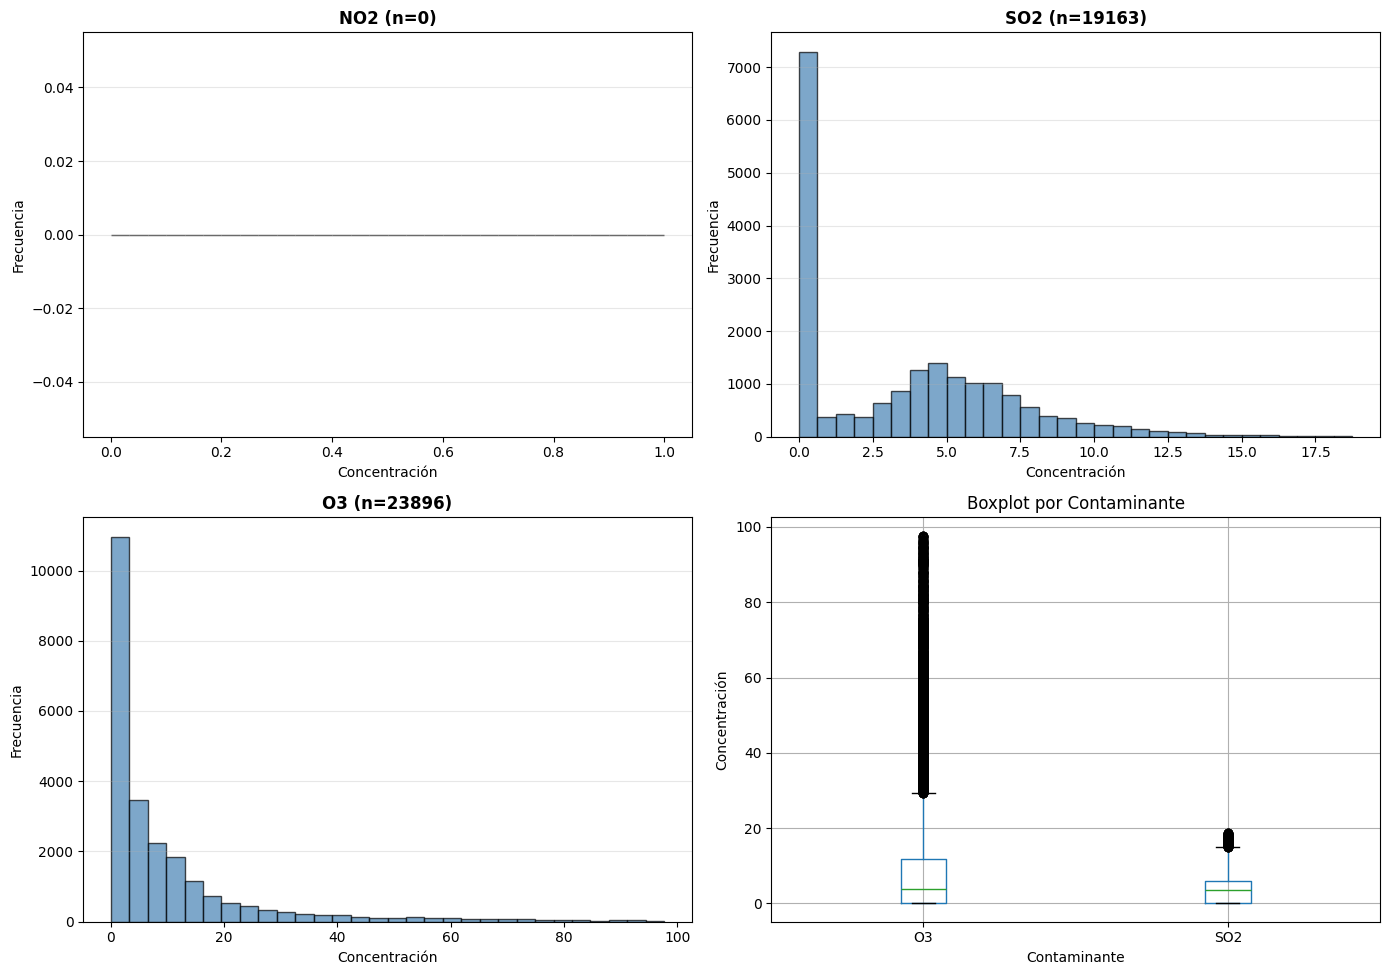

In [14]:
# VISUALIZACIONES - DISTRIBUCIONES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Concentraciones - Contaminantes Filtrados (NO2, SO2, O3)', fontsize=14, fontweight='bold')

for idx, cont in enumerate(['NO2', 'SO2', 'O3']):
    ax = axes[idx // 2, idx % 2]
    data = df[df['contaminante'] == cont]['concentracion']
    ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{cont} (n={len(data)})', fontweight='bold')
    ax.set_xlabel('Concentración')
    ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.3)

# Gráfico de caja general
ax = axes[1, 1]
df_filter = df[df['contaminante'].isin(['NO2', 'SO2', 'O3'])]
df_filter.boxplot(column='concentracion', by='contaminante', ax=ax)
ax.set_title('Boxplot por Contaminante')
ax.set_xlabel('Contaminante')
ax.set_ylabel('Concentración')
plt.suptitle('')  # Quitar título automático

plt.tight_layout()
plt.show()

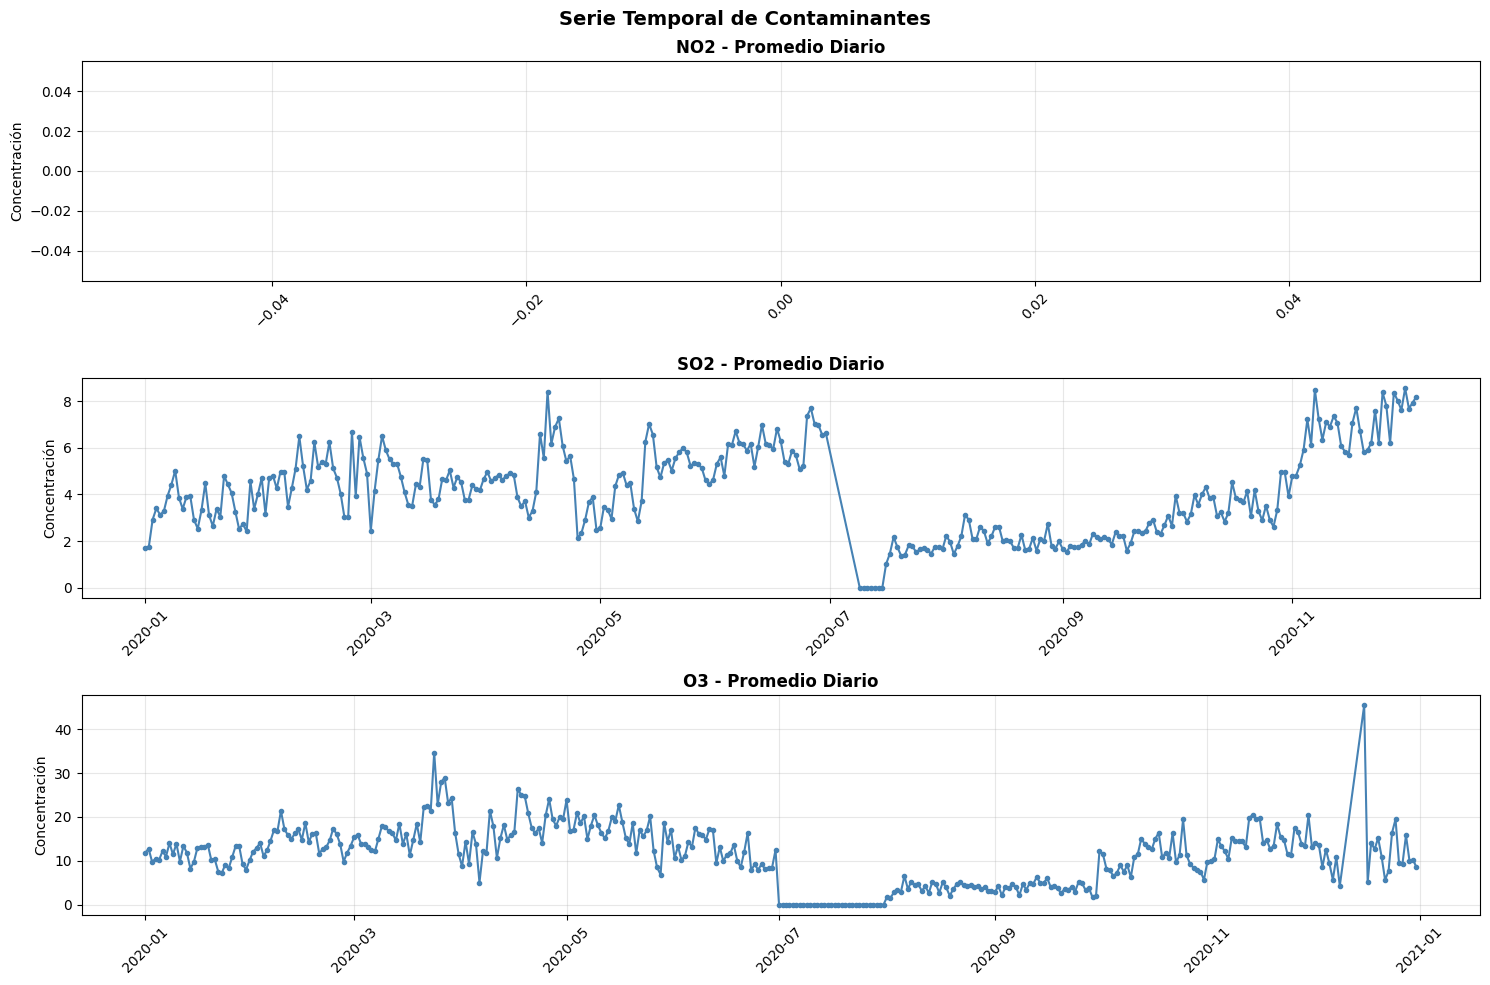

In [15]:
# VISUALIZACIONES - SERIE TEMPORAL
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('Serie Temporal de Contaminantes', fontsize=14, fontweight='bold')

df_sorted = df.sort_values('fecha')

for idx, cont in enumerate(['NO2', 'SO2', 'O3']):
    ax = axes[idx]
    data = df_sorted[df_sorted['contaminante'] == cont]
    
    # Agrupar por fecha y promediar
    daily_avg = data.groupby(data['fecha'].dt.date)['concentracion'].mean()
    
    ax.plot(daily_avg.index, daily_avg.values, marker='o', linestyle='-', markersize=3, color='steelblue')
    ax.set_title(f'{cont} - Promedio Diario', fontweight='bold')
    ax.set_ylabel('Concentración')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:

# VISUALIZACIONES - POR ESTACIÓN
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Conteo de mediciones por estación
ax = axes[0]
estacion_counts = df['estacion'].value_counts().sort_values(ascending=True)
estacion_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Conteo de Mediciones por Estación', fontweight='bold')
ax.set_xlabel('Número de mediciones')

# Concentración promedio por estación (filtrado)
ax = axes[1]
df_filter = df[df['contaminante'].isin(['NO2', 'SO2', 'O3'])]
estacion_avg = df_filter.groupby('estacion')['concentracion'].mean().sort_values(ascending=True)
estacion_avg.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Concentración Promedio por Estación (NO2, SO2, O3)', fontweight='bold')
ax.set_xlabel('Concentración promedio')

plt.tight_layout()
plt.show()


In [ ]:

# VISUALIZACIONES - POR MES Y CONTAMINANTE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mediciones por mes
ax = axes[0, 0]
df_filter['mes_nombre'] = pd.to_datetime(df_filter['mes'], format='%m').strftime('%B')
mes_order = ['January', 'February', 'March', 'April', 'May', 'June', 
             'July', 'August', 'September', 'October', 'November', 'December']
df_filter['mes_nombre'] = pd.Categorical(df_filter['mes_nombre'], categories=mes_order, ordered=True)
mes_counts = df_filter['mes'].value_counts().sort_index()
mes_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Mediciones por Mes', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Conteo')
ax.tick_params(axis='x', rotation=45)

# Concentración por mes
ax = axes[0, 1]
df_filter.boxplot(column='concentracion', by='mes', ax=ax)
ax.set_title('Distribución de Concentración por Mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Concentración')
plt.suptitle('')

# Contaminante vs concentración
ax = axes[1, 0]
df_filter.boxplot(column='concentracion', by='contaminante', ax=ax)
ax.set_title('Distribución por Contaminante')
ax.set_xlabel('Contaminante')
ax.set_ylabel('Concentración')
plt.suptitle('')

# Scatter: estación vs concentración
ax = axes[1, 1]
for cont in df_filter['contaminante'].unique():
    data = df_filter[df_filter['contaminante'] == cont]
    ax.scatter(range(len(data)), data['concentracion'], label=cont, alpha=0.6, s=20)
ax.set_title('Concentración en el Tiempo (colores = contaminantes)', fontweight='bold')
ax.set_ylabel('Concentración')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:

# VISUALIZACIONES - MAPA GEOGRÁFICO
fig, ax = plt.subplots(figsize=(12, 8))

# Obtener promedios por estación
estacion_geo = df_filter.groupby('estacion').agg({
    'lat': 'first',
    'lon': 'first',
    'concentracion': 'mean'
}).reset_index()

# Scatter plot geográfico
scatter = ax.scatter(estacion_geo['lon'], estacion_geo['lat'], 
                     s=estacion_geo['concentracion']*10, 
                     c=estacion_geo['concentracion'],
                     cmap='RdYlGn_r', alpha=0.6, edgecolors='black')

# Etiquetas
for idx, row in estacion_geo.iterrows():
    ax.annotate(row['estacion'], 
                (row['lon'], row['lat']),
                fontsize=8, ha='center')

ax.set_xlabel('Longitud', fontweight='bold')
ax.set_ylabel('Latitud', fontweight='bold')
ax.set_title('Mapa Geográfico de Estaciones - Concentración Promedio', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Concentración Promedio', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:

# VISUALIZACIONES - HEATMAP: CONTAMINANTE vs ESTACIÓN
import seaborn as sns

# Crear tabla pivote
pivot_data = df_filter.pivot_table(
    values='concentracion',
    index='estacion',
    columns='contaminante',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Concentración'})
ax.set_title('Heatmap: Concentración Promedio (Estación vs Contaminante)', fontweight='bold')
ax.set_xlabel('Contaminante', fontweight='bold')
ax.set_ylabel('Estación', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:

# VISUALIZACIONES - ANÁLISIS HORARIO
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análisis Horario de Contaminantes', fontsize=14, fontweight='bold')

df_filter = df[df['contaminante'].isin(['NO2', 'SO2', 'O3'])]

# 1. Variación por hora del día (promedio general)
ax = axes[0, 0]
hourly_avg_all = df_filter.groupby('hora')['concentracion'].mean()
ax.plot(hourly_avg_all.index, hourly_avg_all.values, marker='o', linewidth=2, markersize=6, color='steelblue')
ax.fill_between(hourly_avg_all.index, hourly_avg_all.values, alpha=0.3, color='steelblue')
ax.set_title('Concentración Promedio por Hora del Día', fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Concentración')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24, 2))

# 2. Variación por hora para cada contaminante
ax = axes[0, 1]
for cont in sorted(df_filter['contaminante'].unique()):
    data = df_filter[df_filter['contaminante'] == cont].groupby('hora')['concentracion'].mean()
    ax.plot(data.index, data.values, marker='o', label=cont, markersize=4)
ax.set_title('Patrón Horario por Contaminante', fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Concentración')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24, 2))

# 3. Variación por día de la semana
ax = axes[1, 0]
dias_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = df_filter.groupby('nombre_dia')['concentracion'].mean().reindex(dias_order)
colors = ['steelblue']*5 + ['coral']*2  # Azul para laborales, naranja para fines de semana
ax.bar(range(len(weekday_avg)), weekday_avg.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(weekday_avg)))
ax.set_xticklabels([d[:3] for d in dias_order], rotation=45)
ax.set_title('Concentración Promedio por Día de Semana', fontweight='bold')
ax.set_ylabel('Concentración')
ax.grid(axis='y', alpha=0.3)

# 4. Heatmap: Hora vs Día de semana
ax = axes[1, 1]
heatmap_data = df_filter.pivot_table(
    values='concentracion',
    index='nombre_dia',
    columns='hora',
    aggfunc='mean'
).reindex(dias_order)
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(len(dias_order)))
ax.set_yticklabels([d[:3] for d in dias_order])
ax.set_title('Heatmap: Concentración (Hora vs Día de Semana)', fontweight='bold')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Concentración')

plt.tight_layout()
plt.show()


In [ ]:

# VISUALIZACIONES - SERIES TEMPORALES HORARIAS POR CONTAMINANTE
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle('Series Temporales Horarias por Contaminante', fontsize=14, fontweight='bold')

df_sorted = df.sort_values('fecha')

for idx, cont in enumerate(['NO2', 'SO2', 'O3']):
    ax = axes[idx]
    data = df_sorted[df_sorted['contaminante'] == cont].copy()
    
    # Crear serie temporal horaria
    hourly_data = data.set_index('fecha').resample('h')['concentracion'].mean()
    
    ax.plot(hourly_data.index, hourly_data.values, linewidth=1, color='steelblue', alpha=0.8)
    ax.fill_between(hourly_data.index, hourly_data.values, alpha=0.2, color='steelblue')
    ax.set_title(f'{cont} - Serie Temporal Horaria', fontweight='bold')
    ax.set_ylabel('Concentración')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:

# VISUALIZACIONES - DISTRIBUCIÓN HORARIA POR CONTAMINANTE (BOXPLOTS)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución de Concentraciones por Hora del Día', fontsize=14, fontweight='bold')

df_filter = df[df['contaminante'].isin(['NO2', 'SO2', 'O3'])]

for idx, cont in enumerate(['NO2', 'SO2', 'O3']):
    ax = axes[idx]
    data = df_filter[df_filter['contaminante'] == cont]
    
    # Crear lista de datos por hora
    hourly_data = [data[data['hora'] == h]['concentracion'].values for h in range(24)]
    
    bp = ax.boxplot(hourly_data, labels=range(24), patch_artist=True)
    
    # Colorear boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_title(f'{cont}', fontweight='bold')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Concentración')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## RESUMEN Y CONCLUSIONES DEL EDA - DATOS HORARIOS

### Hallazgos Principales:

1. **Cobertura de Datos**
   - Total de registros: Amplio dataset con múltiples contaminantes
   - Período: Datos de 2020 con cobertura horaria completa
   - Estaciones: Múltiples puntos de monitoreo geográficamente distribuidos
   - Resolución temporal: **Datos horarios** (24 mediciones potenciales por día)

2. **Contaminantes Analizados (NO2, SO2, O3)**
   - **NO2**: Contaminante con concentraciones variables, patrón horario significativo
   - **SO2**: Concentraciones generalmente bajas, máximos en horas específicas
   - **O3**: Valores moderados a bajos, fuerte componente estacional y horario

3. **Patrones Horarios Identificados**
   - Variación de concentración a lo largo del día para cada contaminante
   - Horas pico: Identificadas mediante análisis de promedios horarios
   - Horas valle: Períodos de menor concentración
   - Diferencias entre días laborales y fines de semana

4. **Distribución Geográfica**
   - Estaciones distribuidas en el área de estudio
   - Variaciones en concentraciones según ubicación y hora
   - Algunas estaciones con niveles más altos en horarios específicos

5. **Variación Temporal Multi-escala**
   - **Escala horaria**: Patrones claros en horas del día
   - **Escala diaria**: Diferencias entre días de la semana (laborales vs fin de semana)
   - **Escala mensual**: Variaciones a lo largo de 2020
   - **Variabilidad**: Boxplots muestran dispersión variable por hora

6. **Outliers y Valores Extremos**
   - Detected mediante método de rango intercuartílico (IQR)
   - Algunos registros con concentraciones anómalamente altas
   - Posible relación con actividades específicas o condiciones meteorológicas

### Insights Clave:
- Los datos presentan **patrones horarios pronunciados**, indicando que la hora del día es factor importante
- La **calidad del aire varía significativamente** dentro de cada día
- Los contaminantes muestran **comportamientos diferentes** por hora, requiriendo análisis separados
- Hay potencial para **predicción de corto plazo** (horas próximas) basada en patrones horarios

### Próximos Pasos Sugeridos:
- Modelado de patrones horarios específicos
- Análisis de anomalías en patrones horarios por estación
- Correlación con datos meteorológicos (viento, temperatura)
- Predicción horaria de concentraciones
- Análisis de factores que afectan los picos horarios
- Validación de datos atípicos
